In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import matplotlib.pyplot as plt
import json

In [26]:
# ======================
# CONFIG
# ======================
data_dir = "D:/post_kuliah/assessment/project-2/classification_dataset"
batch_size = 32
epochs = 20
lr = 0.001

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [27]:
# ======================
# TRANSFORM
# ======================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [28]:
# ======================
# DATASET
# ======================
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(data_dir, "valid"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)

class_names = train_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['depan', 'miring_kanan', 'miring_kiri', 'nunduk']


In [29]:
# ======================
# MODEL
# ======================
model = models.mobilenet_v3_small(pretrained=True)

# ganti layer terakhir
model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)

model = model.to(device)

In [30]:
# ======================
# LOSS & OPTIMIZER
# ======================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)


In [31]:
# ======================
# HISTORY STORAGE
# ======================
train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_val_acc = 0

In [32]:
# ======================
# TRAINING LOOP
# ======================
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")

    # TRAIN
    model.train()
    train_loss = 0
    correct = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()

    train_acc = correct / len(train_dataset)

    # VALIDATION
    model.eval()
    val_loss = 0
    correct = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()

    val_acc = correct / len(val_dataset)

    # simpan history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    # save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_mobilenetv3_model.pth")
        print("✅ Best model updated!")


Epoch 1/20


100%|██████████| 82/82 [00:15<00:00,  5.37it/s]


Train Loss: 17.0447 | Train Acc: 0.9249
Val   Loss: 25.7379 | Val   Acc: 0.8349
✅ Best model updated!

Epoch 2/20


100%|██████████| 82/82 [00:17<00:00,  4.70it/s]


Train Loss: 4.5593 | Train Acc: 0.9847
Val   Loss: 11.5933 | Val   Acc: 0.8846
✅ Best model updated!

Epoch 3/20


...

Train Loss: 6.2573 | Train Acc: 0.9816
Val   Loss: 204.7300 | Val   Acc: 0.6591

Epoch 19/20


100%|██████████| 82/82 [00:17<00:00,  4.64it/s]


Train Loss: 6.3659 | Train Acc: 0.9831
Val   Loss: 2.0865 | Val   Acc: 0.9839

Epoch 20/20


100%|██████████| 82/82 [00:17<00:00,  4.63it/s]


Train Loss: 1.9093 | Train Acc: 0.9943
Val   Loss: 0.4766 | Val   Acc: 0.9919


In [33]:
# ======================
# SAVE LAST MODEL
# ======================
torch.save(model.state_dict(), "last_mobilenetv3_model.pth")

# ======================
# SAVE HISTORY
# ======================
history = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "train_acc": train_accs,
    "val_acc": val_accs
}

with open("training_history.json", "w") as f:
    json.dump(history, f)

print("📁 History saved!")

📁 History saved!


📊 Grafik disimpan!


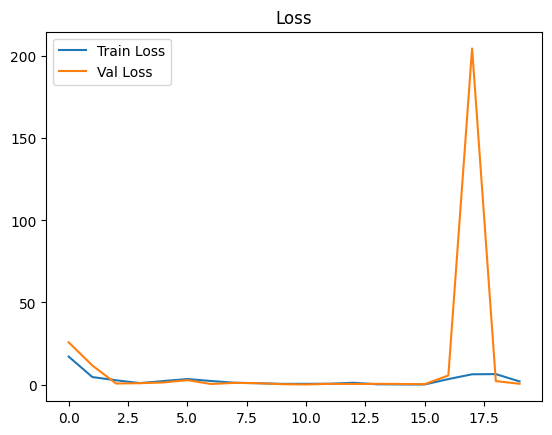

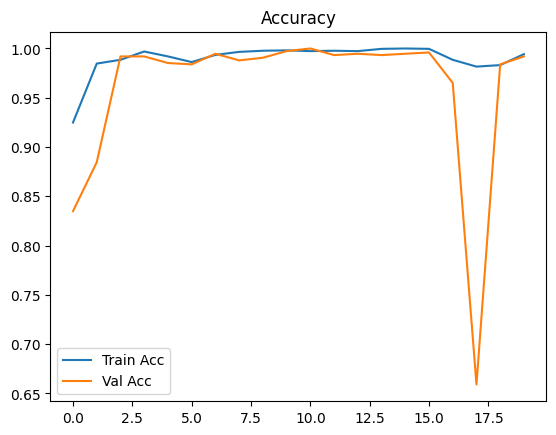

In [34]:
# ======================
# PLOT GRAPH
# ======================
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.savefig("loss.png")

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.savefig("accuracy.png")

print("📊 Grafik disimpan!")